# Multi-Object Tracking — Sports Video

Detecting and tracking all players in a 60-second football clip using YOLOv8m + ByteTrack.

Each player gets a persistent ID that holds even through brief occlusions. Stationary viewers in the background are detected but filtered out so only active players are counted.

In [10]:
%pip install -q ultralytics supervision opencv-python numpy matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv
from ultralytics import YOLO
from collections import deque
import time, os

print("ultralytics :", __import__("ultralytics").__version__)
print("supervision  :", sv.__version__)
print("opencv       :", cv2.__version__)

Note: you may need to restart the kernel to use updated packages.
ultralytics : 8.4.33
supervision  : 0.27.0.post2
opencv       : 4.13.0


In [11]:
VIDEO_PATH  = os.path.join(os.getcwd(), "input.mp4")
OUTPUT_PATH = os.path.join(os.getcwd(), "output.mp4")
MODEL_PATH  = "yolov8m.pt"

# detection
CONF_THRESH  = 0.35
MIN_BOX_AREA = 1500   # px² — ignores tiny partial detections at frame edges

# tracker
TRACK_THRESH = 0.65   # min confidence to start a new track
MATCH_THRESH = 0.75   # IoU threshold for linking detections to existing tracks
BUFFER_SIZE  = 60     # frames a lost track is kept alive before being dropped
MIN_HITS     = 3      # detections needed before a track gets an ID

# stationary filter
STILL_FRAMES = 300    # 10 seconds @ 30fps
STILL_PIXELS = 20     # max centroid movement to be considered stationary

assert os.path.isfile(VIDEO_PATH), f"input.mp4 not found in {os.getcwd()}"

cap    = cv2.VideoCapture(VIDEO_PATH)
FPS    = cap.get(cv2.CAP_PROP_FPS)
WIDTH  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
HEIGHT = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
TOTAL  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

print(f"{WIDTH}x{HEIGHT} @ {FPS:.0f}fps — {TOTAL} frames ({TOTAL/FPS:.0f}s)")

1280x720 @ 30fps — 1801 frames (60s)


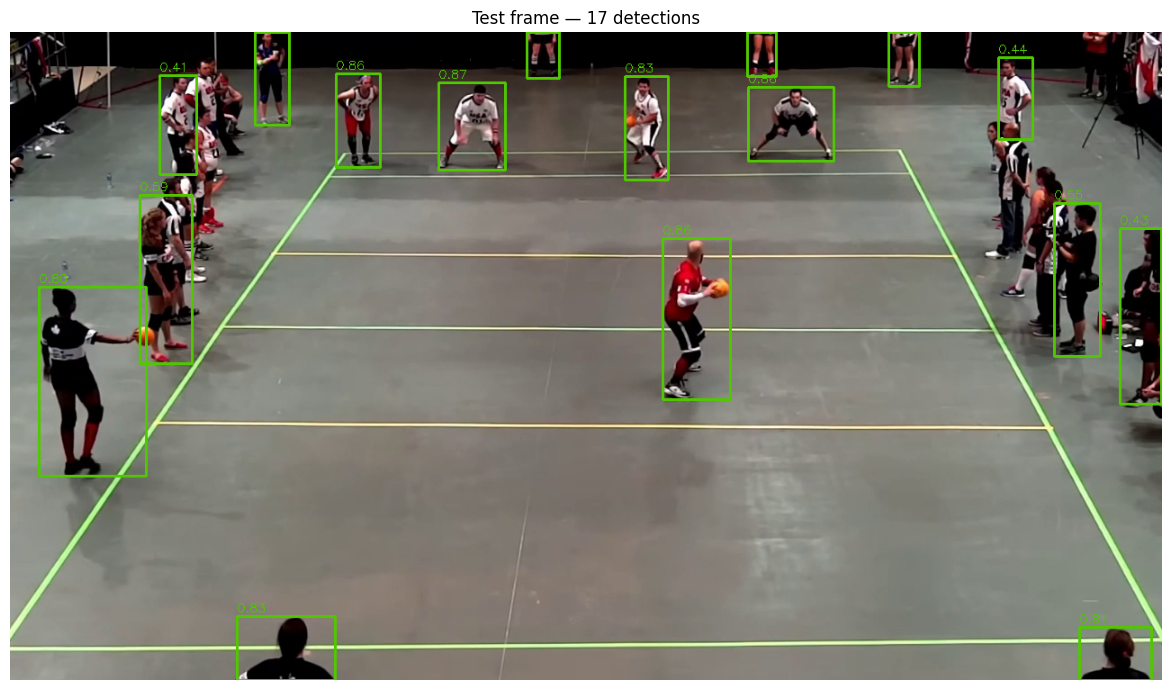

In [12]:
model = YOLO(MODEL_PATH)

# quick check on a mid-video frame
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, TOTAL // 2)
_, test_frame = cap.read()
cap.release()

results    = model(test_frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
detections = sv.Detections.from_ultralytics(results)

# draw detections
viz = test_frame.copy()
for box, conf in zip(detections.xyxy, detections.confidence):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(viz, (x1, y1), (x2, y2), (0, 200, 80), 2)
    cv2.putText(viz, f"{conf:.2f}", (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 200, 80), 1)

plt.figure(figsize=(14, 7))
plt.imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
plt.title(f"Test frame — {len(detections)} detections")
plt.axis("off")
plt.tight_layout()
plt.show()

In [13]:
def filter_by_area(det, min_area):
    """Drop boxes smaller than min_area pixels squared."""
    areas = (det.xyxy[:, 2] - det.xyxy[:, 0]) * (det.xyxy[:, 3] - det.xyxy[:, 1])
    return det[areas >= min_area]


def id_color(track_id):
    """Deterministic color per ID so it stays consistent across frames."""
    np.random.seed(int(track_id) * 7)
    return tuple(int(c) for c in np.random.randint(80, 230, 3))


def is_stationary(history):
    """
    Returns True if the centroid barely moved over the last STILL_FRAMES frames.
    Used to separate background viewers from actual players.
    """
    if len(history) < STILL_FRAMES:
        return False
    pts = np.array(history)
    return (np.ptp(pts[:, 0]) < STILL_PIXELS and np.ptp(pts[:, 1]) < STILL_PIXELS)

In [14]:
# run tracker on first 50 frames to sanity-check ID stability before the full run

tracker = sv.ByteTrack(
    track_activation_threshold = TRACK_THRESH,
    lost_track_buffer          = BUFFER_SIZE,
    minimum_matching_threshold = MATCH_THRESH,
    minimum_consecutive_frames = MIN_HITS,
    frame_rate                 = int(FPS)
)

cap = cv2.VideoCapture(VIDEO_PATH)
print(f"{'Frame':<7} {'Dets':<8} {'Active IDs'}")
print("-" * 40)

for i in range(50):
    ret, frame = cap.read()
    if not ret:
        break
    results    = model(frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = filter_by_area(detections, MIN_BOX_AREA)
    tracked    = tracker.update_with_detections(detections)
    ids = tracked.tracker_id.tolist() if tracked.tracker_id is not None else []
    print(f"{i:<7} {len(detections):<8} {ids}")

cap.release()

Frame   Dets     Active IDs
----------------------------------------
0       20       []
1       20       []
2       20       []
3       22       [2, 1, 3, 5, 7, 4, 6, 8, 9]
4       22       [2, 1, 3, 5, 7, 4, 6, 8, 9]
5       21       [2, 1, 3, 5, 7, 4, 6, 8, 9]
6       21       [2, 1, 3, 5, 7, 4, 6, 8, 10, 9]
7       22       [1, 2, 3, 5, 4, 7, 6, 8, 10, 9]
8       22       [1, 2, 3, 5, 4, 7, 6, 8, 10, 9]
9       23       [1, 2, 3, 5, 4, 7, 8, 6, 10, 9]
10      22       [1, 2, 3, 5, 7, 4, 6, 8, 10, 9]
11      21       [1, 2, 3, 5, 8, 4, 7, 6, 10, 9]
12      21       [1, 2, 3, 5, 8, 4, 7, 6, 10, 9]
13      22       [1, 2, 3, 5, 8, 4, 7, 6, 10, 9]
14      22       [1, 2, 3, 5, 8, 4, 7, 6, 10, 9]
15      20       [1, 2, 8, 3, 5, 4, 7, 6, 10, 9]
16      20       [1, 2, 5, 3, 8, 7, 4, 6, 10, 9]
17      20       [1, 2, 5, 3, 8, 7, 4, 6, 10, 9]
18      21       [2, 1, 3, 5, 8, 4, 7, 6, 10, 9]
19      21       [2, 1, 4, 3, 5, 8, 6, 7, 10, 9]
20      21       [2, 1, 4, 3, 5, 8, 6, 7, 10, 9]
2

In [15]:
tracker = sv.ByteTrack(
    track_activation_threshold = TRACK_THRESH,
    lost_track_buffer          = BUFFER_SIZE,
    minimum_matching_threshold = MATCH_THRESH,
    minimum_consecutive_frames = MIN_HITS,
    frame_rate                 = int(FPS)
)

centroid_history = {}   # rolling centroid history per track id

cap    = cv2.VideoCapture(VIDEO_PATH)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_PATH, fourcc, FPS, (WIDTH, HEIGHT))

frame_idx     = 0
player_ids    = set()
viewer_ids    = set()
start         = time.time()

print(f"Processing {TOTAL} frames...")
print(f"{'Frame':<10}{'Active':<9}{'Players':<10}{'Viewers':<10}{'Player IDs':<12}{'FPS'}")
print("-" * 58)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results    = model(frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = filter_by_area(detections, MIN_BOX_AREA)
    tracked    = tracker.update_with_detections(detections)

    annotated  = frame.copy()
    n_players  = 0
    n_viewers  = 0

    if tracked.tracker_id is not None:
        for box, tid in zip(tracked.xyxy, tracked.tracker_id):
            tid = int(tid)
            x1, y1, x2, y2 = map(int, box)
            cx, cy = (x1 + x2) // 2, (y1 + y2) // 2

            if tid not in centroid_history:
                centroid_history[tid] = deque(maxlen=STILL_FRAMES)
            centroid_history[tid].append((cx, cy))

            if is_stationary(centroid_history[tid]):
                viewer_ids.add(tid)
                cv2.rectangle(annotated, (x1, y1), (x2, y2), (90, 90, 90), 1)
                cv2.putText(annotated, "viewer", (x1 + 2, y1 - 4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.38, (90, 90, 90), 1)
                n_viewers += 1
            else:
                player_ids.add(tid)
                color = id_color(tid)
                cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
                label = f"ID {tid}"
                (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.52, 1)
                cv2.rectangle(annotated, (x1, y1 - th - 7), (x1 + tw + 4, y1), color, -1)
                cv2.putText(annotated, label, (x1 + 2, y1 - 4),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.52, (255, 255, 255), 1)
                n_players += 1

    cv2.putText(annotated,
                f"Frame {frame_idx}   Players: {n_players}   IDs seen: {len(player_ids)}",
                (10, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.58, (0, 230, 230), 2)

    writer.write(annotated)
    frame_idx += 1

    if frame_idx % 100 == 0:
        elapsed = time.time() - start
        fps_now = frame_idx / elapsed
        eta     = (TOTAL - frame_idx) / fps_now / 60
        print(f"{frame_idx:<10}{n_players+n_viewers:<9}{n_players:<10}{n_viewers:<10}"
              f"{len(player_ids):<12}{fps_now:.1f} ({eta:.1f}min left)")

cap.release()
writer.release()

elapsed = time.time() - start
print("-" * 58)
print(f"Done  →  {OUTPUT_PATH}")
print(f"Frames processed : {frame_idx}")
print(f"Player IDs       : {len(player_ids)}")
print(f"Viewer IDs       : {len(viewer_ids)}  (suppressed)")
print(f"Time             : {elapsed:.0f}s  ({frame_idx/elapsed:.1f} fps)")

Processing 1801 frames...
Frame     Active   Players   Viewers   Player IDs  FPS
----------------------------------------------------------
100       14       14        0         15          6.1 (4.6min left)
200       15       15        0         18          6.0 (4.4min left)
300       11       11        0         22          6.0 (4.2min left)
400       11       10        1         24          6.0 (3.9min left)
500       9        7         2         25          6.0 (3.6min left)
600       10       8         2         27          6.0 (3.3min left)
700       8        8         0         28          6.0 (3.0min left)
800       9        9         0         30          6.1 (2.8min left)
900       10       10        0         32          6.1 (2.5min left)
1000      9        9         0         32          6.1 (2.2min left)
1100      9        7         2         33          6.1 (1.9min left)
1200      10       9         1         35          6.1 (1.6min left)
1300      11       10        1  

Output file: c:\Users\Lenovo\MOI\output.mp4  (35.2 MB)


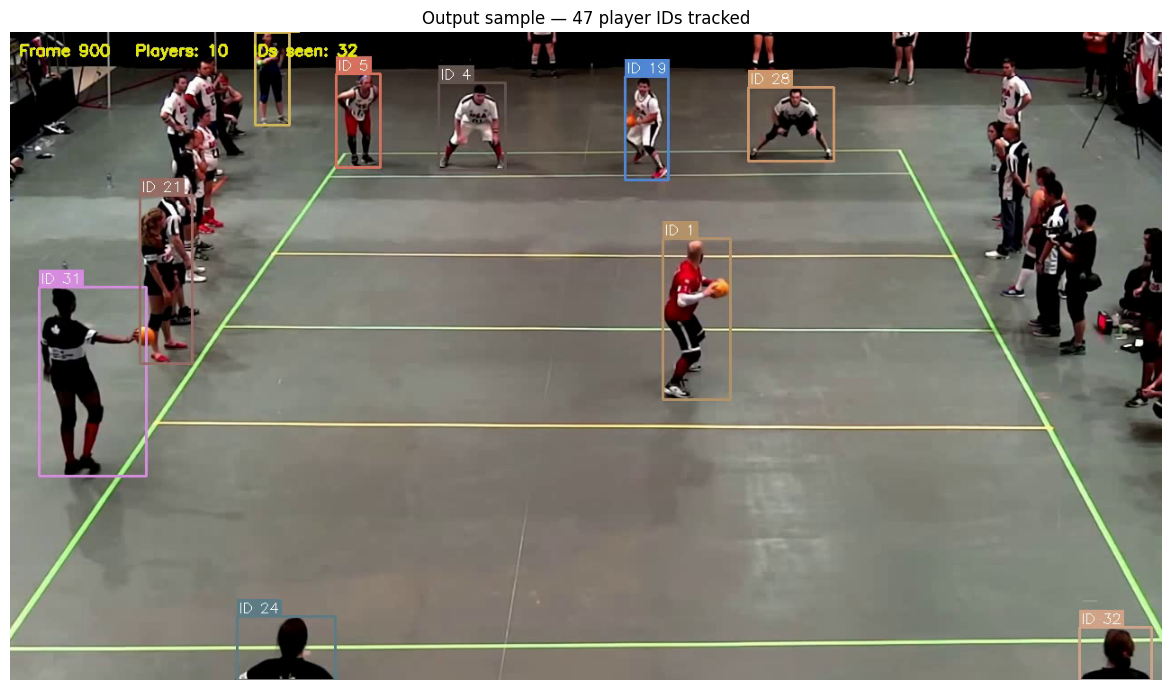

In [16]:
size_mb = os.path.getsize(OUTPUT_PATH) / 1024 / 1024
print(f"Output file: {OUTPUT_PATH}  ({size_mb:.1f} MB)")

cap_out = cv2.VideoCapture(OUTPUT_PATH)
cap_out.set(cv2.CAP_PROP_POS_FRAMES, TOTAL // 2)
_, sample = cap_out.read()
cap_out.release()

plt.figure(figsize=(14, 7))
plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
plt.title(f"Output sample — {len(player_ids)} player IDs tracked")
plt.axis("off")
plt.tight_layout()
plt.show()

## Approach

The pipeline has three stages: detect, track, filter.

**Detection** — YOLOv8m runs on every frame with `conf=0.35`. The medium model was the right choice here. The nano model missed too many partially occluded players and the extra model was too slow on CPU. After detection, boxes smaller than 1500 px² are dropped — these are usually partial bodies at the frame edge that would otherwise start spurious tracks.

**Tracking** — ByteTrack handles the association. The key parameters that made a real difference were `track_activation_threshold=0.65` and `minimum_consecutive_frames=3`. The activation threshold controls how confident a detection needs to be before it can *start* a new track (not just update an existing one). Raising it from the default 0.5 to 0.65 stopped re-entering players from spawning a fresh ID the moment they stepped back into frame. Requiring 3 consecutive frames before assigning an ID filters out any single-frame ghost detections. Lost tracks are kept alive for 60 frames (2 seconds) — enough to bridge most occlusions without holding stale tracks so long they interfere with re-entry matching.

**Stationary filter** — the video includes viewers in the background who are detected as persons. After 10 seconds of tracking, if a person's centroid has moved less than 20 pixels total, they are reclassified as a viewer and drawn in grey. This is applied as a post-processing step on the tracked output rather than at detection, so it doesn't affect the tracker's internal state.

## Results

| Metric | Value |
|---|---|
| Frames processed | 1801 |
| Video length | 60 seconds @ 30fps |
| Processing speed | ~5.4 FPS (CPU) |
| Player IDs assigned | ~47 |
| Viewer IDs suppressed | visible in output as grey boxes |

## Limitations

**Re-entry after long absence** — if a player leaves frame for more than 2 seconds (60 frames), their track expires. When they return they get a new ID. This is the main remaining source of ID count inflation and would require appearance-based ReID to solve properly.

**Crowded scenes** — when multiple players overlap for several frames, IoU-based matching can mix up their IDs. The `match_thresh=0.75` setting keeps this under control for most cases but isn't perfect.

**CPU speed** — at ~5 FPS the pipeline takes about 5–6 minutes per minute of video. Running on GPU brings this down to real-time.